# Lecture 9 — Supervised Learning for Machine Condition

**01211271 Industrial AI and IoT** · Electromechanical Manufacturing Engineering

---

Lecture 8 ended with a table: 2928 rows, twelve features, one label per row, and a
run id telling you which acquisition each row came from. Building that table was
most of the work. This lecture spends the table.

We will put five classifiers on the same data, choose between them honestly, and —
because the winner has to run on an ESP32 in eight weeks' time — measure not only
how accurate each one is but how large it is and how much arithmetic it costs per
decision. Those two questions turn out to have the same answer, which is not what
most people expect.

## Learning objectives

By the end of this notebook you should be able to:

1. Say whether a problem is regression or classification, and what changes when it is.
2. Describe how a decision tree, logistic regression, a linear SVM, k-NN and a
   random forest each reach a decision — and draw the shape of the boundary each one
   can make.
3. Recognise underfitting and overfitting from a validation curve and from a
   learning curve, and say which one more data would fix.
4. Explain what regularisation does to a linear model, and read a regularisation path.
5. Run a train / validation / test protocol that does not lie to you.
6. Compare models on accuracy **and** on deployed size and inference cost.

## Prerequisites

Lecture 8 in full — windowing, the twelve features, and above all splitting by run.
If the phrase *"the random split invented 0.123 of accuracy"* does not ring a bell,
go back before continuing.

## The running example

The same rotor rig. A motor turns a disc on two rolling-element bearings; an
accelerometer on the drive-end housing samples at 2000 Hz. Three states — `normal`,
`imbalance`, `bearing` — and 48 acquisition runs, each with its own shaft speed,
sensor gain, noise floor and frame resonance.

Lecture 9 adds one new acquisition campaign: a **speed sweep** in the healthy state,
used in section 8 to build a virtual tachometer.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
import m2cgen

print("python     ", sys.version.split()[0])
for m in (np, pd, matplotlib, sklearn, m2cgen):
    print(f"{m.__name__:<11}", m.__version__)

plt.rcParams.update({"figure.figsize": (10.5, 3.6), "font.size": 10,
                     "axes.grid": True, "grid.alpha": 0.35,
                     "axes.spines.top": False, "axes.spines.right": False})
BLUE, ORANGE, AQUA, VIOLET, RED = ("#2a78d6", "#eb6834", "#1baf7a",
                                   "#4a3aa7", "#e34948")

python      3.11.15
numpy       2.4.4
pandas      3.0.2
matplotlib  3.10.9
sklearn     1.8.0
m2cgen      0.10.0


## The data

The rig simulator from Lecture 8, unchanged, plus `make_speed_sweep()` at the bottom
for section 8. Re-running it with `seed=7` reproduces exactly the table you exported
as `lecture8_dataset.csv`, so the notebook stays self-contained — but if you kept
that file you can load it instead and the numbers will match.

In [2]:
"""
rig.py — the rotor-rig simulator shared by Lectures 8-14
01211271 Industrial AI and IoT

Synthetic but physics-motivated vibration data for a small motor-driven rotor rig.

Rig model
---------
A 3-phase induction motor drives a rotor disc supported by two rolling-element
bearings.  A MEMS accelerometer is mounted radially on the drive-end bearing
housing and sampled at fs = 2000 Hz.

Three machine states are simulated:

  normal    : residual unbalance only -> modest 1x shaft-rate component
  imbalance : added trial mass on the disc -> large 1x component
  bearing   : outer-race spall -> periodic impulses at BPFO that ring the
              bearing housing resonance

Outer-race defect frequency, for a bearing with n = 9 balls, ball/pitch
diameter ratio d/D = 0.2 and contact angle 0:

    BPFO = (n/2) * (1 - (d/D) cos(phi)) * f_r = 4.5 * 0.8 * f_r = 3.6 * f_r

so at a nominal 30 Hz shaft rate (1800 rpm) the impulses arrive at 108 Hz.

Every run carries its own nuisance variation -- shaft speed, sensor gain,
broadband noise floor, DC bias and a structural tone.  This is what makes a
random train/test split across overlapping windows dishonest: the model can
memorise the run, not the fault.

Lecture 8 built the classification dataset from make_dataset().  Lecture 9 adds
make_speed_sweep(), a separate acquisition campaign used for the soft-sensor
thread: the rig is run across its speed range in the healthy state so that a
regression model can learn to read shaft speed off the vibration alone.
"""

import numpy as np

# ----------------------------------------------------------------- constants
FS = 2000.0                 # sampling rate, Hz
RUN_SECONDS = 4.0           # length of one acquisition run
RUNS_PER_CLASS = 16
CLASSES = ("normal", "imbalance", "bearing")

WIN = 256                   # default window length, samples (128 ms)
HOP = 128                   # 50 % overlap

F_RESONANCE = 600.0         # bearing housing resonance, Hz
TAU_RING = 0.0012           # impulse ring-down time constant, s
BPFO_RATIO = 3.6            # outer-race defect order

# Fixed analysis bands, Hz.  Shaft speed wanders over 28-32 Hz, so the bands
# are wide enough to hold the order they are named for without a tachometer.
BANDS = {
    "e_1x":   (20.0, 42.0),     # shaft rate
    "e_2x":   (48.0, 78.0),     # twice shaft rate
    "e_bpfo": (90.0, 132.0),    # outer-race defect order
    "e_hi":   (400.0, 900.0),   # housing resonance region
}

FEATURE_NAMES = [
    "mean", "rms", "std", "ptp", "crest", "kurt", "zcr",
    "dom_freq", "e_1x", "e_2x", "e_bpfo", "e_hi",
]


# ------------------------------------------------------------ signal synthesis
def _run_params(rng, state):
    """Nuisance parameters that vary from one acquisition run to the next."""
    return dict(
        f_r=rng.uniform(28.0, 32.0),          # shaft rate, Hz
        gain=rng.uniform(0.85, 1.25),         # sensor / mounting gain
        noise=rng.uniform(0.04, 0.20),        # broadband floor, g rms
        bias=rng.uniform(-0.06, 0.06),        # accelerometer DC offset, g
        f_struct=rng.uniform(150.0, 700.0),   # frame resonance -- a confounder
        a_struct=rng.uniform(0.03, 0.15),
        a_1x=(rng.uniform(0.20, 0.38) if state != "imbalance"
              else rng.uniform(0.58, 1.10)),
        a_imp=(rng.uniform(0.45, 1.40) if state == "bearing" else 0.0),
    )


def make_run(rng, state, seconds=RUN_SECONDS, fs=FS):
    """Synthesise one acquisition run.  Returns (signal, params)."""
    p = _run_params(rng, state)
    n = int(seconds * fs)
    t = np.arange(n) / fs

    ph = rng.uniform(0, 2 * np.pi, 4)
    x = (p["a_1x"] * np.sin(2 * np.pi * p["f_r"] * t + ph[0])
         + 0.32 * p["a_1x"] * np.sin(2 * np.pi * 2 * p["f_r"] * t + ph[1])
         + 0.12 * p["a_1x"] * np.sin(2 * np.pi * 3 * p["f_r"] * t + ph[2])
         + p["a_struct"] * np.sin(2 * np.pi * p["f_struct"] * t + ph[3]))

    if p["a_imp"] > 0:
        f_bpfo = BPFO_RATIO * p["f_r"]
        period = fs / f_bpfo
        k = 0
        while True:
            # 1 % random slip, as real rolling elements do
            idx = int(k * period * (1.0 + rng.normal(0, 0.01)))
            if idx >= n:
                break
            tail = np.arange(n - idx) / fs
            ring = (p["a_imp"] * rng.uniform(0.75, 1.25)
                    * np.exp(-tail / TAU_RING)
                    * np.sin(2 * np.pi * F_RESONANCE * tail))
            x[idx:] += ring
            k += 1

    x = p["gain"] * (x + rng.normal(0, p["noise"], n)) + p["bias"]
    return x.astype(np.float64), p


def make_dataset(seed=7, runs_per_class=RUNS_PER_CLASS):
    """All runs.  Returns list of dicts with signal, label and run id."""
    rng = np.random.default_rng(seed)
    runs, rid = [], 0
    for state in CLASSES:
        for _ in range(runs_per_class):
            x, p = make_run(rng, state)
            runs.append({"x": x, "label": state, "run": rid, "params": p})
            rid += 1
    return runs


# ------------------------------------------------------------------- features
def frame(x, win=WIN, hop=HOP):
    """Slice a 1-D signal into overlapping windows -> (n_windows, win)."""
    n = 1 + (len(x) - win) // hop
    idx = np.arange(win)[None, :] + hop * np.arange(n)[:, None]
    return x[idx]


def time_features(w):
    """Seven time-domain features for each row of w."""
    mean = w.mean(axis=1)
    ac = w - mean[:, None]                      # remove DC before anything else
    rms = np.sqrt((ac ** 2).mean(axis=1))
    std = ac.std(axis=1)
    ptp = np.ptp(w, axis=1)
    peak = np.abs(ac).max(axis=1)
    crest = peak / np.maximum(rms, 1e-12)
    m4 = (ac ** 4).mean(axis=1)
    kurt = m4 / np.maximum(rms, 1e-12) ** 4     # non-excess kurtosis; 3.0 = Gaussian
    zc = np.diff(np.signbit(ac).astype(np.int8), axis=1)
    zcr = np.abs(zc).sum(axis=1) / (w.shape[1] - 1)
    return np.column_stack([mean, rms, std, ptp, crest, kurt, zcr])


def freq_features(w, fs=FS, normalise=True):
    """Dominant frequency plus four band energies.

    normalise=True gives each band as a fraction of the window's total power,
    which makes the feature independent of sensor gain.  normalise=False gives
    the absolute band power, whose units and magnitude differ wildly from the
    time-domain features -- useful for showing when feature scaling matters.
    """
    n = w.shape[1]
    win = np.hanning(n)
    ac = w - w.mean(axis=1, keepdims=True)
    spec = np.abs(np.fft.rfft(ac * win, axis=1)) ** 2
    f = np.fft.rfftfreq(n, 1.0 / fs)
    spec[:, 0] = 0.0                            # DC carries no information here
    total = np.maximum(spec.sum(axis=1), 1e-20)

    dom = f[spec.argmax(axis=1)]
    cols = [dom]
    for lo, hi in BANDS.values():
        m = (f >= lo) & (f < hi)
        band = spec[:, m].sum(axis=1)
        cols.append(band / total if normalise else band)
    return np.column_stack(cols)


def features_of(w, fs=FS, normalise=True):
    """Full 12-feature vector for each row of w."""
    return np.column_stack([time_features(w), freq_features(w, fs, normalise)])


def build_table(runs, win=WIN, hop=HOP, fs=FS, normalise=True):
    """Turn the raw runs into the (X, y, groups) learning problem."""
    X, y, g = [], [], []
    for r in runs:
        w = frame(r["x"], win, hop)
        X.append(features_of(w, fs, normalise))
        y += [r["label"]] * w.shape[0]
        g += [r["run"]] * w.shape[0]
    return np.vstack(X), np.array(y), np.array(g)


def raw_table(runs, win=WIN, hop=HOP):
    """The naive alternative: the raw samples of each window as the features."""
    X, y, g = [], [], []
    for r in runs:
        w = frame(r["x"], win, hop)
        X.append(w)
        y += [r["label"]] * w.shape[0]
        g += [r["run"]] * w.shape[0]
    return np.vstack(X), np.array(y), np.array(g)


# ------------------------------------------------- Lecture 9: the speed sweep
SWEEP_RUNS = 40
SWEEP_FR = (22.0, 40.0)     # stays inside the e_1x band (20-42 Hz)


def make_speed_sweep(seed=11, n_runs=SWEEP_RUNS, seconds=RUN_SECONDS):
    """A healthy-machine speed sweep, for the virtual tachometer.

    The rig has no tachometer.  To build one in software you run the machine
    across its speed range in a known-good state and record the true shaft
    speed from the drive's own setpoint.  Each run still carries its own gain,
    noise floor, bias and frame resonance -- the soft sensor has to work in
    spite of those, not because of them.

    Returns a list of dicts with the signal, the true shaft speed and a run id.
    """
    rng = np.random.default_rng(seed)
    runs = []
    for rid in range(n_runs):
        p = _run_params(rng, "normal")
        p["f_r"] = float(rng.uniform(*SWEEP_FR))
        n = int(seconds * FS)
        t = np.arange(n) / FS
        ph = rng.uniform(0, 2 * np.pi, 4)
        x = (p["a_1x"] * np.sin(2 * np.pi * p["f_r"] * t + ph[0])
             + 0.32 * p["a_1x"] * np.sin(2 * np.pi * 2 * p["f_r"] * t + ph[1])
             + 0.12 * p["a_1x"] * np.sin(2 * np.pi * 3 * p["f_r"] * t + ph[2])
             + p["a_struct"] * np.sin(2 * np.pi * p["f_struct"] * t + ph[3]))
        x = p["gain"] * (x + rng.normal(0, p["noise"], n)) + p["bias"]
        runs.append({"x": x.astype(np.float64), "f_r": p["f_r"],
                     "run": rid, "params": p})
    return runs


def build_speed_table(runs, win=WIN, hop=HOP, fs=FS):
    """(X, y, groups) for the soft sensor.  y is the true shaft speed in Hz."""
    X, y, g = [], [], []
    for r in runs:
        w = frame(r["x"], win, hop)
        X.append(features_of(w, fs))
        y += [r["f_r"]] * w.shape[0]
        g += [r["run"]] * w.shape[0]
    return np.vstack(X), np.array(y), np.array(g)

In [3]:
runs = make_dataset(seed=7)
X, y, groups = build_table(runs)
G = np.unique(groups)
print(f"{X.shape[0]} rows  ×  {X.shape[1]} features,  from {len(G)} runs")
print(pd.Series(y).value_counts().to_string())

2928 rows  ×  12 features,  from 48 runs
normal       976
imbalance    976
bearing      976


## 1. Two tasks, one table

Everything about the pipeline stays the same — the same windows, the same twelve
features, the same rule about splitting by run. Only the **target column** changes,
and with it the question you are answering and the way you score the answer.

| | classification | regression |
|---|---|---|
| question | which state is the machine in? | how fast is the shaft turning? |
| target | one of three labels | a number in Hz |
| where the target comes from | someone had to write it down | the drive's own speed setpoint |
| natural score | accuracy, precision, recall | RMSE, in the units of the target |
| a useless model scores | 0.333 — guessing one of three | the standard deviation of the target |

That last row matters more than it looks. **Always write down what a useless model
scores before you train anything.** Otherwise "RMSE = 1.9 Hz" means nothing: it could
be excellent or it could be worse than predicting the average.

Sections 2–7 are classification. Section 8 is the regression thread.

## 2. Five candidates

Five model families, chosen because between them they cover the range of things a
classifier can be, and because exactly two of them will still be viable when we reach
the ESP32 in Lecture 11.

| model | how it decides | one knob | what it stores |
|---|---|---|---|
| decision tree | a chain of `feature j > t?` questions | `max_depth` | a few nodes |
| logistic regression | weighted sum of features, per class | `C` | 12 weights per class |
| linear SVM | weighted sum, fitted to maximise the margin | `C` | 12 weights per class |
| k-NN | vote of the *k* closest training rows | `k` | **the entire training set** |
| random forest | majority vote of many trees | `max_depth` | every node of every tree |

Read the last column again. Four of these five compress the training data into a
handful of numbers. k-NN does not compress at all — it *is* the training data, which
is why it will lose in section 7 for reasons that have nothing to do with accuracy.

Two of them need the features standardised, and two do not:

```python
# logistic regression, linear SVM, k-NN — distance or coefficients, so SCALE
make_pipeline(StandardScaler(), LogisticRegression(C=1.0))

# decision tree, random forest — only asks "is feature j above t?", so DO NOT bother
DecisionTreeClassifier(max_depth=2)
```

This is the Lecture 8 scaling rule doing real work rather than being a ritual.

## 3. The protocol that does not lie

Lecture 8 established that we split by **run**, never by row. That gave two piles:
train and test. As soon as you have a hyperparameter to choose, two piles are not
enough.

Here is the failure. You try nine tree depths, score each on the test set, and keep
the best. The number you report is now the *maximum* of nine noisy measurements — it
is biased upward, and the more values you tried the worse the bias. You have used the
test set to make a decision, so it is no longer a test set.

The fix is a third pile:

```
  fit on TRAIN  →  choose the hyperparameter on VALIDATION  →  report on TEST, once
```

With 48 runs we use 60 / 20 / 20 — 28 runs to fit, 10 to choose, 10 to report.

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

N_SEEDS = 8

def split3(seed):
    '''60 / 20 / 20 by RUN. Every window of a run stays on one side.'''
    rng = np.random.default_rng(seed)
    p = rng.permutation(G)
    n = len(G)
    a, b = int(0.6 * n), int(0.8 * n)
    return np.isin(groups, p[:a]), np.isin(groups, p[a:b]), np.isin(groups, p[b:])

tr, va, te = split3(0)
for name, m in (("train", tr), ("validation", va), ("test", te)):
    print(f"{name:<11} {m.sum():5d} windows   from {len(np.unique(groups[m])):2d} runs")

train        1708 windows   from 28 runs
validation    610 windows   from 10 runs
test          610 windows   from 10 runs


Note how few *runs* there are on each side. 2928 rows looks like a comfortable
dataset; 48 runs does not. Every result in this notebook is really an experiment on
48 independent observations, and the models are about to tell us so.

## 4. Underfitting and overfitting

A model that is too simple cannot represent the pattern: it scores badly on the
training data *and* on the validation data. That is **underfitting**.

A model that is too complex represents the pattern and the noise: it scores nearly
perfectly on training data and badly on validation data. That is **overfitting**, and
the gap between the two curves is its signature.

The only way to find the middle is to plot both.

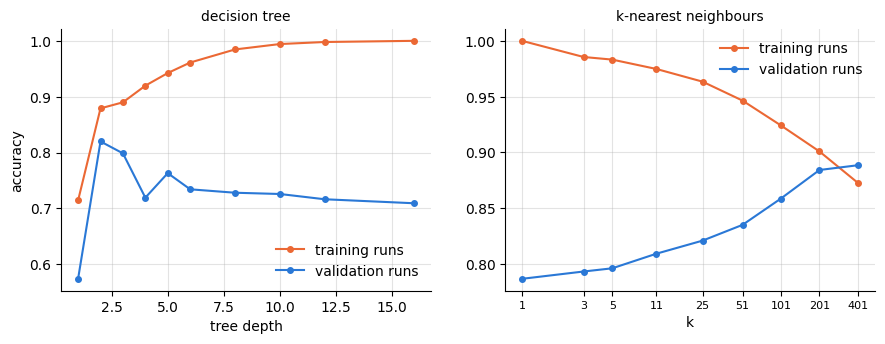

tree : best depth 2  validation 0.820   (depth 16 -> train 1.000, validation 0.709)
k-NN : best k     401  validation 0.889   (k = 1 -> train 1.000, validation 0.787)


In [5]:
DEPTHS = [1, 2, 3, 4, 5, 6, 8, 10, 12, 16]
KS = [1, 3, 5, 11, 25, 51, 101, 201, 401]

def sweep(grid, mk, scale):
    tr_, va_ = np.zeros((len(grid), N_SEEDS)), np.zeros((len(grid), N_SEEDS))
    for s in range(N_SEEDS):
        a, b, _ = split3(s)
        A = StandardScaler().fit(X[a]).transform(X) if scale else X
        for i, h in enumerate(grid):
            m = mk(h).fit(A[a], y[a])
            tr_[i, s], va_[i, s] = m.score(A[a], y[a]), m.score(A[b], y[b])
    return tr_.mean(1), va_.mean(1)

d_tr, d_va = sweep(DEPTHS, lambda h: DecisionTreeClassifier(max_depth=h,
                                                            random_state=0), False)
k_tr, k_va = sweep(KS, lambda h: KNeighborsClassifier(h), True)

fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.4))
ax[0].plot(DEPTHS, d_tr, "-o", color=ORANGE, ms=4, label="training runs")
ax[0].plot(DEPTHS, d_va, "-o", color=BLUE, ms=4, label="validation runs")
ax[0].set_xlabel("tree depth"); ax[0].set_ylabel("accuracy")
ax[0].legend(frameon=False); ax[0].set_title("decision tree", fontsize=10)
ax[1].semilogx(KS, k_tr, "-o", color=ORANGE, ms=4, label="training runs")
ax[1].semilogx(KS, k_va, "-o", color=BLUE, ms=4, label="validation runs")
ax[1].set_xlabel("k"); ax[1].set_xticks(KS); ax[1].set_xticklabels(KS, fontsize=8)
ax[1].minorticks_off(); ax[1].legend(frameon=False)
ax[1].set_title("k-nearest neighbours", fontsize=10)
plt.show()

print(f"tree : best depth {DEPTHS[int(np.argmax(d_va))]}  "
      f"validation {d_va.max():.3f}   (depth 16 -> train {d_tr[-1]:.3f}, "
      f"validation {d_va[-1]:.3f})")
print(f"k-NN : best k     {KS[int(np.argmax(k_va))]}  validation {k_va.max():.3f}   "
      f"(k = 1 -> train {k_tr[0]:.3f}, validation {k_va[0]:.3f})")

Two things to take from this, and the second is the more important.

**First, the shapes are textbook.** The tree's training accuracy climbs to a perfect
1.000 while its validation accuracy peaks early and then falls — the classic
overfitting scissors. k-NN at *k* = 1 scores a perfect 1.000 on training data by
construction, because the nearest neighbour of a training row is itself.

**Second, and specific to this dataset: both models want to be made much simpler than
you would guess.** The tree wants depth 2 — three questions in total. k-NN wants to
average over several hundred neighbours before it will commit.

Why? Because the effective sample size is not 2928. Windows from the same run are
near-duplicates of each other and share that run's speed, gain and noise floor, so
the real number of independent observations is closer to the **28 training runs**.
Any model with more capacity than 28 observations can support will spend that
capacity memorising which run it is looking at.

Note also that Lecture 8 used `max_depth=6` throughout. The validation curve says
that was a poor choice — 6 scores about 0.73 against 0.82 for depth 2. Lecture 8 was
demonstrating leakage, not tuning a model, so it did not matter there. It matters now.

## 5. Learning curves: would more data help?

A validation curve varies model complexity at fixed data. A **learning curve** does
the opposite: it fixes the model and varies how much data it gets. It answers the
question a manager will eventually ask you — *should we spend another week collecting
data?*

Two shapes, two different answers:

* **Curves far apart, training much higher, gap not closing** → the model is
  memorising. More data helps slowly; a simpler model helps immediately.
* **Curves close together and both still rising** → you are limited by data, and
  collecting more will pay.

We plot against the number of **runs**, not rows. Adding more windows from a machine
you have already recorded adds almost no information — that is the same insight as
section 4, drawn differently.

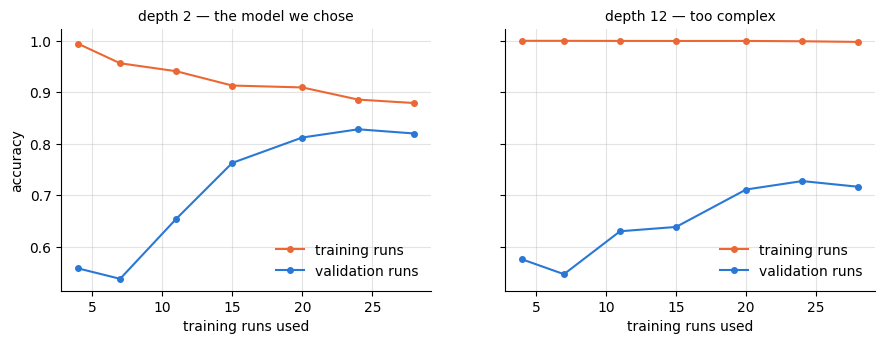

depth  2 : final gap 0.059   validation rose +0.262 over 24 runs
depth 12 : final gap 0.281   validation rose +0.141 over 24 runs


In [6]:
FRACS = [0.15, 0.25, 0.4, 0.55, 0.7, 0.85, 1.0]

def learning_curve(depth):
    tr_, va_ = np.zeros((len(FRACS), N_SEEDS)), np.zeros((len(FRACS), N_SEEDS))
    n_used = []
    for s in range(N_SEEDS):
        rng = np.random.default_rng(100 + s)
        a, b, _ = split3(s)
        tr_runs = np.unique(groups[a]); rng.shuffle(tr_runs)
        for i, f in enumerate(FRACS):
            k = max(3, int(round(f * len(tr_runs))))
            sub = np.isin(groups, tr_runs[:k])
            m = DecisionTreeClassifier(max_depth=depth, random_state=0).fit(X[sub], y[sub])
            tr_[i, s], va_[i, s] = m.score(X[sub], y[sub]), m.score(X[b], y[b])
            if s == 0:
                n_used.append(k)
    return tr_.mean(1), va_.mean(1), n_used

c_tr2, c_va2, n_used = learning_curve(2)
o_tr, o_va, _ = learning_curve(12)

fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.4), sharey=True)
for axi, (t_, v_, ttl) in zip(ax, [(c_tr2, c_va2, "depth 2 — the model we chose"),
                                   (o_tr, o_va, "depth 12 — too complex")]):
    axi.plot(n_used, t_, "-o", color=ORANGE, ms=4, label="training runs")
    axi.plot(n_used, v_, "-o", color=BLUE, ms=4, label="validation runs")
    axi.set_xlabel("training runs used"); axi.set_title(ttl, fontsize=10)
    axi.legend(frameon=False, loc="lower right")
ax[0].set_ylabel("accuracy")
plt.show()

print(f"depth  2 : final gap {c_tr2[-1] - c_va2[-1]:.3f}   "
      f"validation rose {c_va2[-1] - c_va2[0]:+.3f} over {n_used[-1] - n_used[0]} runs")
print(f"depth 12 : final gap {o_tr[-1] - o_va[-1]:.3f}   "
      f"validation rose {o_va[-1] - o_va[0]:+.3f} over {n_used[-1] - n_used[0]} runs")

The depth-2 curves are 0.06 apart and validation is still climbing steeply: this
model is **data-limited**, and recording more runs would pay. The depth-12 curves are
0.28 apart and the gap is not closing: that model is **capacity-limited in the wrong
direction**, and no realistic amount of data will rescue it.

So the honest answer to "should we collect more data?" is: *yes, but only more runs,
and only once you have stopped using a model that cannot use them.*

## 6. Regularisation

A linear model scores each class with a weighted sum of the twelve features. Nothing
stops those weights from growing large, and large weights mean the model is leaning
hard on small differences between features — exactly the differences that are
run-specific noise.

Regularisation adds a penalty on the size of the weights, so the fit has to earn every
unit of weight it uses. In scikit-learn's linear classifiers the knob is `C`, which
is the **inverse** strength:

* small `C` → strong penalty → small weights → simpler model
* large `C` → weak penalty → large weights → the model chases whatever it can

The confusing part is the direction, so say it out loud once: **small C means more
regularisation.**

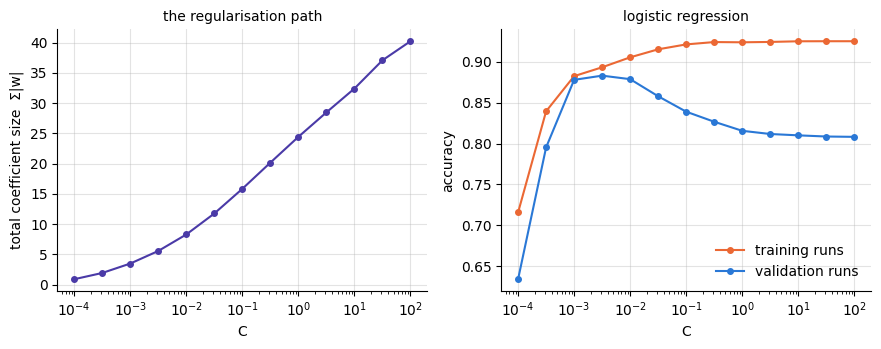

best C = 0.0032   validation 0.883   Sum|w| = 5.5
C = 100          validation 0.808   Sum|w| = 40.2


In [7]:
CS = list(np.logspace(-4, 2, 13))
c_tr, c_va, c_norm = (np.zeros((len(CS), N_SEEDS)) for _ in range(3))
for s in range(N_SEEDS):
    a, b, _ = split3(s)
    A = StandardScaler().fit(X[a]).transform(X)
    for i, Cv in enumerate(CS):
        m = LogisticRegression(C=Cv, max_iter=4000).fit(A[a], y[a])
        c_tr[i, s], c_va[i, s] = m.score(A[a], y[a]), m.score(A[b], y[b])
        c_norm[i, s] = np.abs(m.coef_).sum()

fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.4))
ax[0].semilogx(CS, c_norm.mean(1), "-o", color=VIOLET, ms=4)
ax[0].set_xlabel("C"); ax[0].set_ylabel("total coefficient size  Σ|w|")
ax[0].set_title("the regularisation path", fontsize=10)
ax[1].semilogx(CS, c_tr.mean(1), "-o", color=ORANGE, ms=4, label="training runs")
ax[1].semilogx(CS, c_va.mean(1), "-o", color=BLUE, ms=4, label="validation runs")
ax[1].set_xlabel("C"); ax[1].set_ylabel("accuracy"); ax[1].legend(frameon=False)
ax[1].set_title("logistic regression", fontsize=10)
plt.show()

bc = int(np.argmax(c_va.mean(1)))
print(f"best C = {CS[bc]:.2g}   validation {c_va.mean(1)[bc]:.3f}   "
      f"Sum|w| = {c_norm.mean(1)[bc]:.1f}")
print(f"C = 100          validation {c_va.mean(1)[-1]:.3f}   "
      f"Sum|w| = {c_norm.mean(1)[-1]:.1f}")

Look at the two curves in the right panel together. **Training accuracy is nearly
flat across four decades of `C`** — from the training data's point of view it barely
matters what you choose. Validation accuracy is not flat at all: it peaks around
C = 0.0032 and loses about 0.075 by C = 100.

If you had only ever looked at training accuracy you would have concluded that
regularisation does nothing here. It is the validation runs — machines the model has
never seen — that reveal the cost.

There is a bonus for us: the well-regularised model is also the *smaller* model. Its
coefficients total about a twelfth of the unregularised version's. In Lecture 11 those
coefficients become constants in a MicroPython file, and small, stable numbers are
easier to quantise.

## 7. The comparison — accuracy is only half of it

Now the real experiment. For each of the five families: tune its one hyperparameter
on the validation runs, refit on train + validation, and score once on the test runs.
Repeat over 8 different splits.

Then measure two more things that a course on *industrial* AI cannot ignore:

* **deployed size** — how many bytes of model have to live on the device. We measure
  it by actually exporting each model with `m2cgen`, the tool Lecture 11 will use to
  turn a scikit-learn model into MicroPython. k-NN cannot be exported at all, so we
  count what it would have to carry: the whole training set.
* **inference cost** — how much arithmetic one decision takes.

In [8]:
import m2cgen as m2c

GRIDS = {
 "decision tree": ([1, 2, 3, 4, 5, 6, 8, 10, 12],
                   lambda h: DecisionTreeClassifier(max_depth=h, random_state=0), False),
 "logistic reg.": (list(np.logspace(-4, 2, 13)),
                   lambda h: LogisticRegression(C=h, max_iter=4000), True),
 "linear SVM":    (list(np.logspace(-4, 2, 13)),
                   lambda h: LinearSVC(C=h, max_iter=20000), True),
 "k-NN":          ([1, 3, 5, 11, 25, 51, 101, 201, 401],
                   lambda h: KNeighborsClassifier(h), True),
 "random forest": ([2, 3, 4, 6, 8, None],
                   lambda h: RandomForestClassifier(100, max_depth=h,
                                                    random_state=0, n_jobs=-1), False),
}

scores, chosen = {}, {}
for name, (grid, mk, scale) in GRIDS.items():
    per_seed = []
    for s in range(N_SEEDS):
        a, b, c = split3(s)
        A = StandardScaler().fit(X[a]).transform(X) if scale else X
        best, bh = -1.0, None
        for h in grid:                       # choose on VALIDATION
            v = mk(h).fit(A[a], y[a]).score(A[b], y[b])
            if v > best:
                best, bh = v, h
        m = mk(bh).fit(A[a | b], y[a | b])   # refit on train + validation
        per_seed.append(m.score(A[c], y[c])) # report on TEST, once
        chosen.setdefault(name, []).append(bh)
    scores[name] = np.array(per_seed)

base = scores["decision tree"]
tab = pd.DataFrame({
    "test accuracy": {k: v.mean() for k, v in scores.items()},
    "sd over splits": {k: v.std() for k, v in scores.items()},
    "gain vs tree": {k: (v - base).mean() for k, v in scores.items()},
    "± s.e. of gain": {k: (v - base).std() / np.sqrt(N_SEEDS) for k, v in scores.items()},
})
tab.round(3)

,test accuracy,sd over splits,gain vs tree,± s.e. of gain
decision tree,0.827,0.070,0.000,0.000
logistic reg.,0.876,0.089,0.049,0.015
linear SVM,0.880,0.083,0.053,0.016
k-NN,0.851,0.104,0.024,0.018
random forest,0.859,0.079,0.032,0.011


Read the `sd over splits` column first: about 0.08 for every model. With only 10 test
runs, a single split is worth very little, and the raw accuracies are not far enough
apart to separate on that basis alone.

The last two columns do better. Because every model saw the **same** splits, we can
subtract per split and compare the differences, which removes the run-to-run variance
that dominates the individual numbers. The standard error of the paired difference is
about 0.015 — five times smaller than the individual spread. On that measure the two
linear models are ahead of the tree by roughly three standard errors, which is a real
effect rather than an accident of splitting.

This is worth generalising: **when comparing models, always compare them on the same
splits and difference the results.** It is free precision.

In [9]:
a0, b0, c0 = split3(0)
fit_rows = int((a0 | b0).sum())
Xs0 = StandardScaler().fit(X[a0]).transform(X)

def typical(name):
    vals = [v for v in chosen[name] if v is not None]
    return max(set(vals), key=vals.count)

rows = []

t = DecisionTreeClassifier(max_depth=typical("decision tree"),
                           random_state=0).fit(X[a0 | b0], y[a0 | b0])
rows.append(["decision tree", typical("decision tree"),
             len(m2c.export_to_python(t).encode()), t.get_depth(),
             f"{t.tree_.node_count} nodes"])

l = LogisticRegression(C=typical("logistic reg."),
                       max_iter=4000).fit(Xs0[a0 | b0], y[a0 | b0])
rows.append(["logistic reg.", round(typical("logistic reg."), 5),
             len(m2c.export_to_python(l).encode()), l.coef_.size,
             f"{l.coef_.size} coefficients"])

v = LinearSVC(C=typical("linear SVM"), max_iter=20000).fit(Xs0[a0 | b0], y[a0 | b0])
rows.append(["linear SVM", round(typical("linear SVM"), 5),
             len(m2c.export_to_python(v).encode()), v.coef_.size,
             f"{v.coef_.size} coefficients"])

rows.append(["k-NN", typical("k-NN"), fit_rows * X.shape[1] * 4,
             fit_rows * X.shape[1], f"all {fit_rows} training rows"])

f = RandomForestClassifier(100, max_depth=typical("random forest"),
                           random_state=0, n_jobs=-1).fit(X[a0 | b0], y[a0 | b0])
rows.append(["random forest", typical("random forest"),
             len(m2c.export_to_python(f).encode()),
             sum(e.get_depth() for e in f.estimators_),
             f"{sum(e.tree_.node_count for e in f.estimators_)} nodes"])

d = RandomForestClassifier(random_state=0, n_jobs=-1).fit(X[a0 | b0], y[a0 | b0])
rows.append(["random forest, untuned", "defaults",
             len(m2c.export_to_python(d).encode()),
             sum(e.get_depth() for e in d.estimators_),
             f"{sum(e.tree_.node_count for e in d.estimators_)} nodes"])

cost = pd.DataFrame(rows, columns=["model", "chosen knob", "bytes",
                                   "ops per decision", "what it stores"])
cost["accuracy"] = [scores[m].mean() if m in scores else
                    float(np.mean([RandomForestClassifier(random_state=0, n_jobs=-1)
                                   .fit(X[aa | bb], y[aa | bb]).score(X[cc], y[cc])
                                   for aa, bb, cc in (split3(s) for s in range(N_SEEDS))]))
                    for m in cost["model"]]
cost.set_index("model").round(3)

,chosen knob,bytes,ops per decision,what it stores,accuracy
model,,,,,
decision tree,2,303,2,5 nodes,0.827
logistic reg.,0.00316,1294,36,36 coefficients,0.876
linear SVM,0.0001,1322,36,36 coefficients,0.880
k-NN,401,111264,27816,all 2318 training rows,0.851
random forest,2,38233,200,614 nodes,0.859
"random forest, untuned",defaults,1556017,1485,17990 nodes,0.822


This table is the point of the lecture.

**The two smallest models are the two most accurate.** The linear SVM carries 36
coefficients in about 1.3 KB and does 36 multiply-accumulates per decision. The random
forest a student writes by default — `RandomForestClassifier()`, no arguments —
carries about 18 000 nodes across 1.5 MB of generated code, does hundreds of
comparisons per decision, and is *less* accurate.

Three separate reasons converge on the same answer here:

1. **The data is small in the way that counts.** 48 runs cannot support a
   high-capacity model, so capacity buys memorisation rather than skill.
2. **The features already did the hard work.** Lecture 8 turned raw vibration into
   twelve physically meaningful numbers. Once `e_1x` and `e_hi` exist, the classes are
   close to linearly separable, and a linear model is exactly the right shape.
3. **k-NN's problem is not size but structure.** At 111 KB it would technically fit in
   the ESP32's RAM — but it must compute 27 816 arithmetic operations per decision
   against the linear SVM's 36, and that cost grows every time you record another run.
   A model whose inference cost grows with your dataset cannot be deployed to a device
   that will run for years.

Do not over-generalise this to "linear models always win". The honest conclusion is
narrower and more useful: **model capacity has to match the number of independent
observations, and on this rig that number is 48.** Give the same pipeline 5000 runs
from 200 real machines and the forest would very likely take the lead.

## 8. The regression thread: a virtual tachometer

The rig has no tachometer. Shaft speed matters — it sets the 1× line, the bearing
defect frequencies, and the expected vibration level — so being able to read it off
the accelerometer alone is worth having. This is a **soft sensor** (or virtual
sensor): a measurement you compute instead of installing.

The data is a separate acquisition campaign, `make_speed_sweep()`: 40 healthy runs
spread across 22–40 Hz, with the true speed taken from the drive setpoint. Same
twelve features, same split-by-run rule, new target.

In [10]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupShuffleSplit

sweep_runs = make_speed_sweep(seed=11)
Xr, yr, gr = build_speed_table(sweep_runs)
print(f"{Xr.shape[0]} windows from {len(np.unique(gr))} runs, "
      f"shaft speed {yr.min():.1f}–{yr.max():.1f} Hz")

def reg_rmse(A, mk, want_pred=False):
    out, pred, true = [], None, None
    for s in range(N_SEEDS):
        t_, e_ = next(GroupShuffleSplit(1, test_size=0.3,
                                        random_state=s).split(A, yr, gr))
        p = mk().fit(A[t_], yr[t_]).predict(A[e_])
        out.append(np.sqrt(((p - yr[e_]) ** 2).mean()))
        if s == 0:
            pred, true = p, yr[e_]
    return (float(np.mean(out)), pred, true) if want_pred else float(np.mean(out))

ridge = lambda: make_pipeline(StandardScaler(), Ridge(1.0))
di = FEATURE_NAMES.index("dom_freq")

print(f"\nuseless baseline (predict the mean) : {yr.std():.2f} Hz")
print(f"dom_freq used directly as the answer: "
      f"{np.sqrt(((Xr[:, di] - yr) ** 2).mean()):.2f} Hz")
r12, pred12, true12 = reg_rmse(Xr, ridge, want_pred=True)
print(f"ridge on the 12 features            : {r12:.2f} Hz")
print(f"random forest on the 12 features    : "
      f"{reg_rmse(Xr, lambda: RandomForestRegressor(100, random_state=0, n_jobs=-1)):.2f} Hz")

2440 windows from 40 runs, shaft speed 24.3–39.1 Hz

useless baseline (predict the mean) : 4.47 Hz
dom_freq used directly as the answer: 2.35 Hz
ridge on the 12 features            : 1.90 Hz


random forest on the 12 features    : 2.15 Hz


The soft sensor works: 4.47 Hz down to 1.90 Hz. But now look at what happens when we
try to improve it by using a stronger model — the random forest lands in the same
place. Every model plateaus around 1.9 Hz.

**When every model gives the same answer, the limit is not in the models.** It is in
the features. At a 256-sample window and 2000 Hz, the FFT bins are 7.81 Hz apart, so
`dom_freq` can only take a handful of distinct values across a speed range that is
only 18 Hz wide. The resolution was destroyed in Lecture 8, before any model existed.

The fix is a better feature, not a better model. **Parabolic interpolation** fits a
parabola through the log-magnitude of the peak bin and its two neighbours and reports
the vertex, recovering sub-bin frequency resolution for the cost of about ten
arithmetic operations.

ridge on 12 features + interpolated peak: 0.35 Hz
dom_freq takes 3 distinct values; the interpolated peak takes 2197


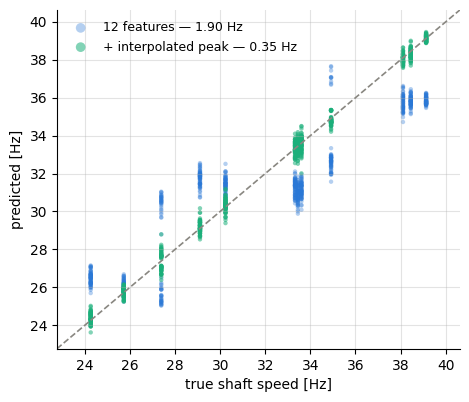

In [11]:
def peak_interp(runs_, win=WIN, hop=HOP):
    '''Parabolic interpolation of the spectral peak -> sub-bin frequency, in Hz.'''
    out = []
    for r in runs_:
        w = frame(r["x"], win, hop)
        ac = w - w.mean(1, keepdims=True)
        sp = np.abs(np.fft.rfft(ac * np.hanning(win), axis=1)) ** 2
        sp[:, 0] = 0.0
        k = np.clip(sp.argmax(1), 1, sp.shape[1] - 2)
        idx = np.arange(len(k))
        lg = lambda j: np.log(sp[idx, j] + 1e-30)
        a_, b_, c_ = lg(k - 1), lg(k), lg(k + 1)
        out.append((k + 0.5 * (a_ - c_) / (a_ - 2 * b_ + c_)) * FS / win)
    return np.concatenate(out)

f_interp = peak_interp(sweep_runs)
Xr_plus = np.column_stack([Xr, f_interp])
r13, pred13, true13 = reg_rmse(Xr_plus, ridge, want_pred=True)
print(f"ridge on 12 features + interpolated peak: {r13:.2f} Hz")
print(f"dom_freq takes {len(np.unique(Xr[:, di]))} distinct values; "
      f"the interpolated peak takes {len(np.unique(f_interp.round(3)))}")

fig, ax = plt.subplots(figsize=(5.2, 4.4))
lims = [yr.min() - 1.5, yr.max() + 1.5]
ax.plot(lims, lims, "--", color="#898781", lw=1.2)
ax.scatter(true12, pred12, s=10, alpha=0.35, color=BLUE, edgecolors="none",
           label=f"12 features — {r12:.2f} Hz")
ax.scatter(true13, pred13, s=10, alpha=0.55, color=AQUA, edgecolors="none",
           label=f"+ interpolated peak — {r13:.2f} Hz")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("true shaft speed [Hz]"); ax.set_ylabel("predicted [Hz]")
ax.legend(frameon=False, markerscale=2.2, fontsize=9)
plt.show()

A 5× improvement from one feature, after two different model families had both
stalled. Keep the diagnostic:

> If several different model families plateau at the same error, stop tuning models
> and go back to the features.

This is the positive counterpart to Lecture 8's `e_bpfo`, which looked essential and
carried nothing. Features are hypotheses in both directions — some you keep are
worthless, and some you never thought of are decisive.

## 9. End to end: choose one model and write it down

Everything above, once, producing the artefact Lecture 11 will deploy.

In [12]:
import json

a, b, c = split3(0)
scaler = StandardScaler().fit(X[a])
A = scaler.transform(X)

best, bh = -1.0, None
for Cv in np.logspace(-4, 2, 13):                      # choose on validation
    v = LinearSVC(C=Cv, max_iter=20000).fit(A[a], y[a]).score(A[b], y[b])
    if v > best:
        best, bh = v, Cv

final = LinearSVC(C=bh, max_iter=20000).fit(A[a | b], y[a | b])   # refit
print(f"chosen C = {bh:.2g}   validation {best:.3f}")
print(f"TEST accuracy (opened once): {final.score(A[c], y[c]):.3f}")

bundle = {
    "lecture": 9,
    "model": "LinearSVC",
    "C": float(bh),
    "feature_names": list(FEATURE_NAMES),
    "classes": list(final.classes_),
    "scaler_mean": [float(v) for v in scaler.mean_],
    "scaler_scale": [float(v) for v in scaler.scale_],
    "coef": [[float(v) for v in row] for row in final.coef_],
    "intercept": [float(v) for v in final.intercept_],
    "window": int(WIN), "hop": int(HOP), "fs": int(FS),
}
with open("lecture9_model.json", "w") as fh:
    json.dump(bundle, fh, indent=1)

n_numbers = final.coef_.size + final.intercept_.size + 2 * len(scaler.mean_)
print(f"\nsaved lecture9_model.json — {n_numbers} numbers in total")
print("this file is the input to Lecture 11 -- keep it")

chosen C = 0.0032   validation 0.857
TEST accuracy (opened once): 0.857

saved lecture9_model.json — 63 numbers in total
this file is the input to Lecture 11 -- keep it


Two things worth noticing before you move on.

The test accuracy printed above is **0.857**, while section 7 reported **0.880** for
the linear SVM. Both are correct: 0.880 is the average over eight splits, and this is
one particular split. With ten test runs, a single number carries a standard deviation
of about 0.08 — which is exactly why section 7 averaged, and why you should never
quote a single split as though it were precise.

The chosen `C` also differs from the one section 7 picked most often. Different
training runs favour slightly different regularisation strengths, and anywhere in the
range 0.0001 to 0.01 the validation curve is essentially flat. A hyperparameter whose
exact value does not matter is good news: it means the choice is robust.

Now count what is in that file: 36 coefficients, 3 intercepts, and 24 scaler constants —
**63 numbers**. That is the entire trained model. At four bytes each it is 252 bytes
of data, and the MicroPython that evaluates it is a double loop you could write from
memory.

That is what "this model deploys" actually means, and it is why Lecture 11 will be a
short lecture.

## What to remember

1. **Regression and classification differ only in the target column** — and in what a
   useless model scores. Write that number down before you train anything.
2. **Three piles, not two.** Fit on train, choose on validation, report on test once.
   A test set you have optimised against is a validation set.
3. **Underfitting**: both curves low and together. **Overfitting**: a wide gap that
   does not close. The validation curve tells you which.
4. **A learning curve answers "should we collect more data?"** — and on this rig the
   x-axis is runs, not rows.
5. **Small C means more regularisation.** Training accuracy will not tell you where to
   set it; validation will.
6. **Compare models on shared splits and difference the results.** The paired standard
   error here is five times smaller than the raw spread.
7. **Match capacity to the number of independent observations.** 2928 rows, 48 runs —
   and every model asked to be simplified.
8. **Measure size and inference cost alongside accuracy.** On this problem the
   smallest model is also the best one, and the default random forest is 1177× larger
   and worse.
9. **If every model plateaus at the same error, fix the features.** One interpolated
   spectral peak beat every model upgrade by 5×.

## Exercises

1. **The knob you did not tune.** `DecisionTreeClassifier` also takes
   `min_samples_leaf`. Fix `max_depth=None` and tune `min_samples_leaf` over
   `[1, 5, 20, 50, 200, 500]` on the validation runs instead. Does it reach the same
   accuracy as tuning depth? Which knob would you rather explain to a colleague?

2. **How much does the third pile cost?** Re-run section 7 for the linear SVM using
   only train/test, choosing `C` on the test set. Report both numbers. How much
   accuracy did the dishonest protocol appear to gain, and how does that compare with
   the 0.123 leakage of Lecture 8?

3. **Cross-validation instead of a fixed validation set.** Replace the single
   validation split with `GroupKFold(n_splits=5)` on the training runs. Does the
   chosen hyperparameter become more stable across the 8 seeds? At what cost in
   compute?

4. **Where does the linear model look?** Print `final.coef_` from section 9 as a
   DataFrame indexed by `FEATURE_NAMES`. Which three features carry the largest
   weights for each class? Does `e_bpfo` — the band Lecture 8 showed was useless —
   get a small weight, as it should?

5. **Class-by-class performance.** Accuracy hides which state is being confused with
   which. Build the confusion matrix for the section 9 model on the test runs. Which
   pair of states does it mix up, and does the answer match what you saw in the
   decision-boundary plots?

6. **Buy accuracy with data.** Regenerate the dataset with `runs_per_class=32` instead
   of 16 and re-run the section 7 comparison. Does the ranking change? Does the
   *tuned* complexity change — does the tree now want to be deeper?

7. **A cheaper soft sensor.** The interpolated peak needs an FFT. Estimate the RMSE
   you could reach on shaft speed using only zero-crossing rate after a band-pass
   filter around 20–45 Hz. Is it good enough to replace the FFT on the ESP32?

8. **Towards Lecture 11.** Write a pure-Python function — no NumPy — that reads
   `lecture9_model.json`, applies the scaler, computes the three class scores and
   returns the argmax. Check it against `final.predict()` on 50 test windows. Count
   its multiplications.

## References

**Models and model selection**

* Hastie, T., Tibshirani, R. and Friedman, J. (2009). *The Elements of Statistical
  Learning*, 2nd ed. Springer. Chapter 7 on model assessment and selection is the
  standard treatment of everything in sections 3–6.
* Cawley, G. C. and Talbot, N. L. C. (2010). *On over-fitting in model selection and
  subsequent selection bias in performance evaluation.* Journal of Machine Learning
  Research, 11, 2079–2107. The paper behind section 3.
* Raschka, S. (2018). *Model evaluation, model selection, and algorithm selection in
  machine learning.* arXiv:1811.12808.
* Dietterich, T. G. (1998). *Approximate statistical tests for comparing supervised
  classification learning algorithms.* Neural Computation, 10(7), 1895–1923. Why
  paired comparisons on shared splits are the right tool.

**Condition monitoring and soft sensors**

* Lei, Y. et al. (2020). *Applications of machine learning to machine fault diagnosis:
  a review and roadmap.* Mechanical Systems and Signal Processing, 138, 106587.
* Kadlec, P., Gabrys, B. and Strandt, S. (2009). *Data-driven soft sensors in the
  process industry.* Computers & Chemical Engineering, 33(4), 795–814.
* Gasior, M. and Gonzalez, J. L. (2004). *Improving FFT frequency measurement
  resolution by parabolic and Gaussian spectrum interpolation.* AIP Conference
  Proceedings, 732, 276–285. The method used in section 8.

**Tools**

* scikit-learn user guide, *Cross-validation* and *Tuning the hyper-parameters of an
  estimator*: https://scikit-learn.org/stable/modules/grid_search.html
* m2cgen — transpiling trained models into plain code:
  https://github.com/BayesWitnesses/m2cgen

Generated by Claude and customized by

<div align="center">
<img src="https://raw.githubusercontent.com/dewdotninja/sharing-github/refs/heads/master/dewninja_logo50.jpg" alt="dewninja"/>
</div>
<div align="center">dew.ninja 2026</div>